# visualize tile

This notebook provides tools for inspecting tiles from the global snowmelt runoff onset dataset.

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import contextily as ctx
import matplotlib.pyplot as plt
import xyzservices as xyz
from global_snowmelt_runoff_onset.config import Config, Tile
import easysnowdata

In [2]:
config = Config('config/global_config_v9.txt')

SAS token is valid until 2026-08-05 06:31 UTC (323.7 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
season

In [3]:
global_ds = xr.open_zarr(config.global_runoff_store, consolidated=True, decode_coords='all')

def view_tile(tile: Tile):


    test_ds = global_ds.rio.clip_box(*tile.get_geobox().boundingbox,crs='EPSG:4326')
    test_ds = test_ds.rio.reproject(test_ds.rio.estimate_utm_crs())

    f,axs=plt.subplots(1,3,figsize=(15,5))
    test_ds['runoff_onset_median'].plot(ax=axs[0],vmin=0,vmax=365)
    axs[0].set_title('2015-2024 median snowmelt runoff onset')

    if 'runoff_onset_std' in test_ds:
        test_ds['runoff_onset_std'].plot(ax=axs[1],cmap='Reds',vmin=0,vmax=60)
        axs[1].set_title('2015-2024 std deviation snowmelt runoff onset')
    elif 'runoff_onset_mad' in test_ds:
        test_ds['runoff_onset_mad'].plot(ax=axs[1],cmap='Reds',vmin=0,vmax=60)
        axs[1].set_title('2015-2024 median absolute deviation snowmelt runoff onset')
    
    if 'temporal_resolution_median' in test_ds:
        test_ds['temporal_resolution_median'].plot(ax=axs[2],cmap='summer',vmin=0,vmax=30)
        axs[2].set_title('Median temporal resolution (days)')

    for ax in axs:
        ctx.add_basemap(ax=ax, crs=test_ds.rio.crs.to_string())
        ax.set_aspect('equal')
        

    f.tight_layout()

    test_ds['runoff_onset'].plot.imshow(col='water_year',col_wrap=5,vmin=0,vmax=365)

    (test_ds['runoff_onset']-test_ds['runoff_onset_median']).plot.imshow(col='water_year',col_wrap=5,vmin=-60,vmax=60,cmap='RdBu')

    test_ds['temporal_resolution'].plot.imshow(col='water_year',col_wrap=5,vmin=0,vmax=30,cmap='summer')

In [4]:
#tile = config.get_tile(23,39)
tile = config.get_tile(23,39)
tile = config.get_tile(12,203)
tile = config.get_tile(13,156)
tile = config.get_tile(23,127)

In [5]:
tile.geobox.explore()

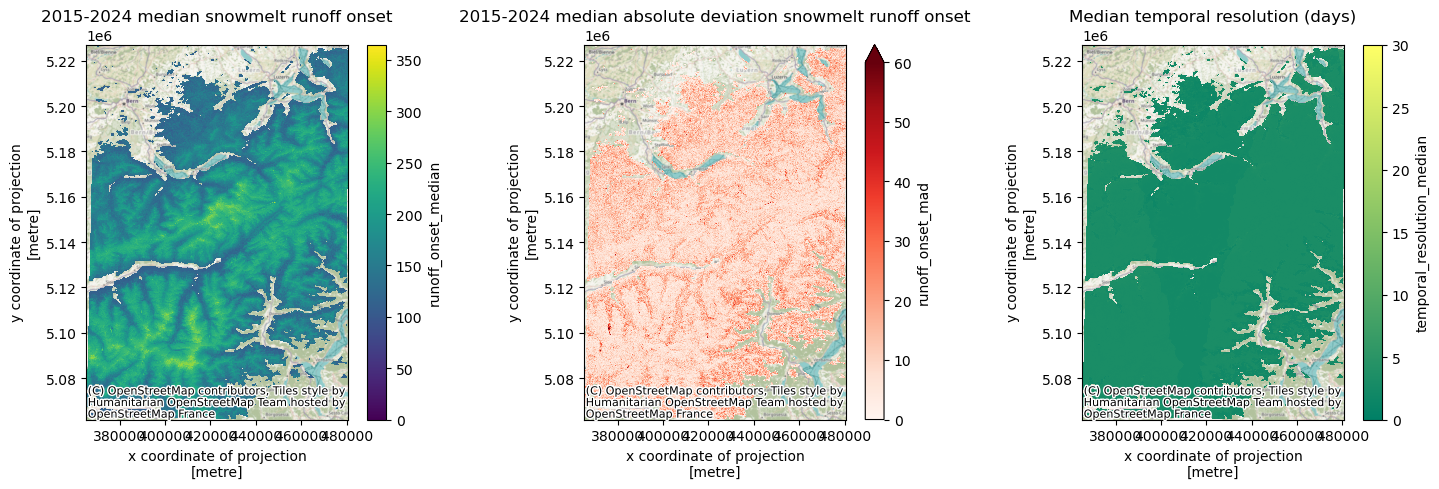

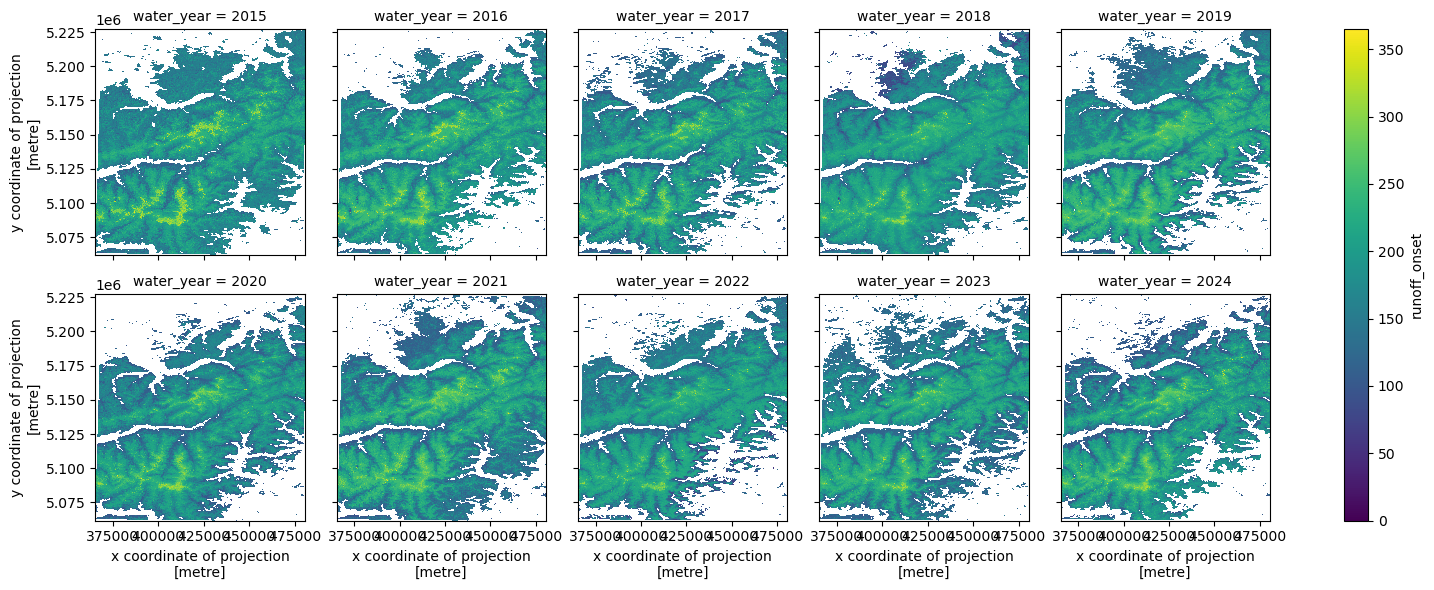

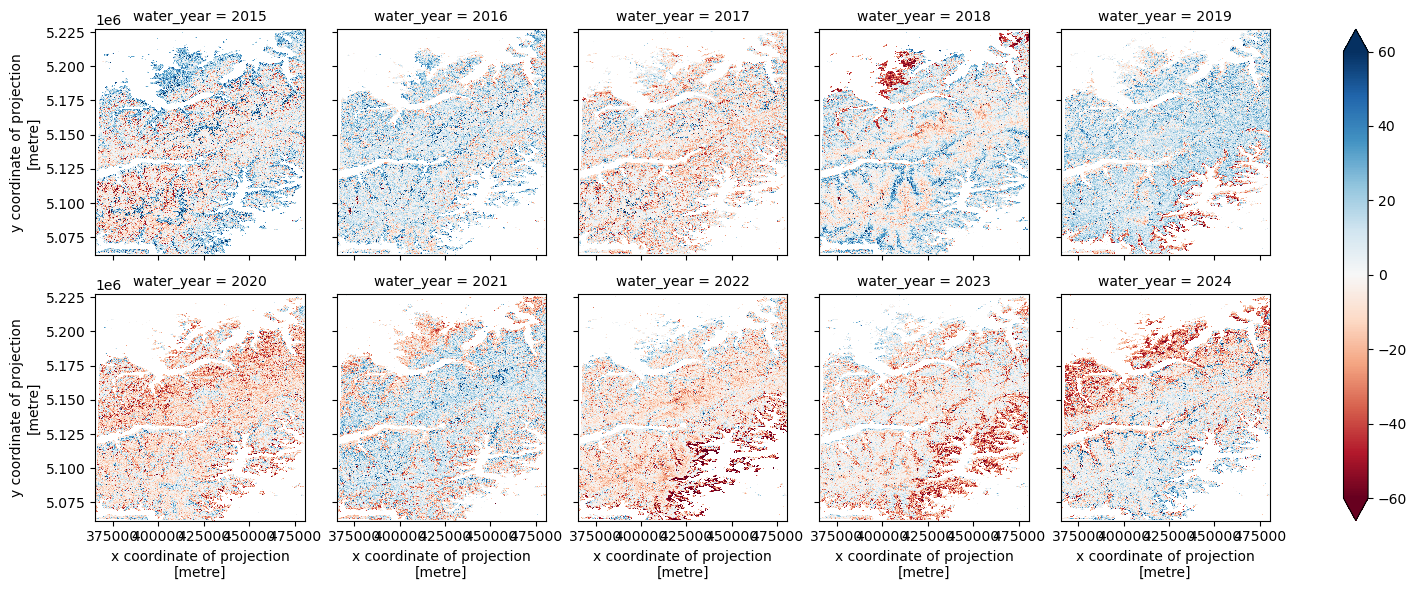

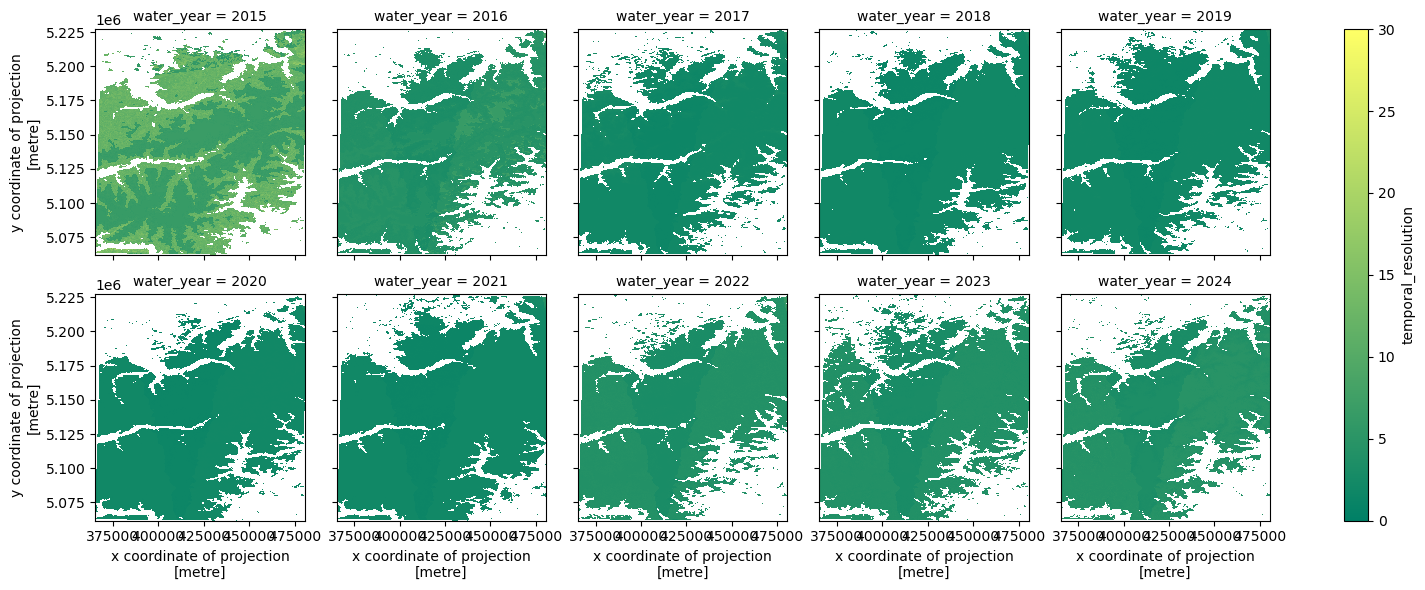

In [6]:
view_tile(tile)